In [29]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt

In [64]:
# outputpath = "/data/users4/xli/MISA/MISA-pytorch/runs/BHI25"
# dir_list = os.listdir(outputpath)

# seed_list = [7, 14, 21]

# Significant models and their labels
# model_list = ['lr0.007_bs200_ab1-0.95_ab2-0.87', 'lr0.0265_bs316_ab1-0.95_ab2-0.81', 'lr0.1_bs200_ab1-0.919_ab2-0.81', 'combined_significant_model']
# model_label_list = [2,4,6,7]

# Full models and their labels
# model_list = ['lr0.0093_bs316_ab1-0.9233_ab2-0.87', 'lr0.029_bs316_ab1-0.95_ab2-0.8484', 'lr0.1_bs200_ab1-0.899_ab2-0.8154', 'combined_full_model']
model_list = ['/data/users3/rsilva/MISA-pytorch/results/2025bhi-rebuttal/res_misa_iva_fMRI_ukb-fmri-iva-100-s1F-800epochs_in-ukb_fMRIpaths_unaffected_100_w-W_gpca_M100_K12_ukb_fMRI.p',
              '/data/users3/rsilva/MISA-pytorch/results/2025bhi-rebuttal/res_misa_iva_fMRI_ukb-fmri-iva-100-s3F-800epochs_in-ukb_fMRIpaths_unaffected_100_w-W_gpca_M100_K12_ukb_fMRI.p',
              '/data/users3/rsilva/MISA-pytorch/results/2025bhi-rebuttal/res_misa_iva_fMRI_ukb-fmri-iva-100-s5F-800epochs_in-ukb_fMRIpaths_unaffected_100_w-W_gpca_M100_K12_ukb_fMRI.p',
              '/data/users3/rsilva/MISA-pytorch/results/2025bhi-rebuttal/res_misa_iva_fmri_ukb-fmri-iva-100-s7F-800epochs_in-ukb_fMRIpaths_unaffected_100_w-W_gpca_M100_K12_ukb_fMRI.p',
            #   '/data/users3/rsilva/MISA-pytorch/results/2025bhi-rebuttal/res_misa_iva_fmri_ukb-fmri-iva-100-s7F_in-ukb_fMRIpaths_unaffected_100_w-W_gpca_M100_K12_ukb_fMRI.p',
              '/data/users3/rsilva/MISA-pytorch/results/2025bhi-rebuttal/res_misa_iva_fMRI_ukb-fmri-iva-100-sDefault-800epochs_in-ukb_fMRIpaths_unaffected_100_w-W_gpca_M100_K12_ukb_fMRI.p']
model_label_list = [1,3,5,7,'Default'] #7\n(800 epochs)',7,'Default']

loss_all = []
# isi_all = []
label_all = []

for j, params in enumerate(model_list): # for each file
    # for seed in seed_list:
    datapath = params #os.path.join(outputpath, params, f"res_sim-siva_dataset100_source12_sample32768_seed{seed}_wpca.p")
    res = pickle.load(open(datapath, "rb"))

    loss = res['loss'][0]
    # isi = res['MISI'][0]

    loss_mean = np.zeros(1+len(loss))
    loss_mean[0] = np.array(1125.053) # initial loss mean
    for i in range(len(loss)):
        loss_mean[i+1] = np.mean(loss[i])
    # isi_mean = np.array(isi)
    loss_all.append(loss_mean)
    # isi_all.append(isi_mean)
    label_all.append(f"Setting {model_label_list[j]}") # Seed {seed}")
label_all[-1] = "\nOriginal\nSetting\nin [10]"

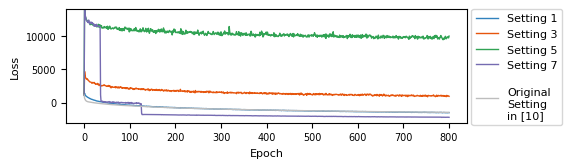

In [65]:
n_epoch = 1 + np.array([800,800,800,800,800]) #200,200])
color_indices = [0, 4, 8, 12, 18] #13, 16]

# set figure size without subplots:
plt.figure(figsize=(6, 1.8))

min_all = [np.min(la) for la in loss_all]
max_all = [np.max(la) for la in loss_all]
for i, l in enumerate(label_all):
    plt.plot(range(n_epoch[i]), loss_all[i], label=l, linewidth=1, color=plt.cm.tab20c(color_indices[i]))
    # plt.plot(range(n_epoch[i]), np.log10(loss_all[i]-min(min_all)+1)+1, label=l, linewidth=1, color=plt.cm.tab20c(color_indices[i]))
plt.xlabel("Epoch", fontsize=8)
plt.ylabel("Loss", fontsize=8)
plt.tick_params(axis='both', which='major', labelsize=7)
# plt.xlim(0,150)
# plt.xlim(700,800)
plt.ylim(-3000,14000)
# plt.ylim(1.95, np.log10(max(max_all) - min(min_all) + 1) + 1.2)
plt.legend(fontsize=8, bbox_to_anchor=(1.25, 1.05))

# for i, l in enumerate(label_all):
#     axes[1].plot(range(n_epoch), isi_all[i], label=l, linewidth=1, color=plt.cm.tab20c(color_indices[i]))
# axes[1].set_xlabel("Epoch", fontsize=16)
# axes[1].set_ylabel("MISI", fontsize=16)
# axes[1].tick_params(axis='both', which='major', labelsize=14)
# axes[1].set_ylim(0.015, 0.8)
# axes[1].set_yscale("log")
# axes[1].legend(fontsize=12, bbox_to_anchor=(1, 1.05))

plt.tight_layout()
# plt.savefig("/data/users4/xli/MISA/MISA-pytorch/runs/BHI25/significant_model_loss_isi.pdf")#, dpi=500
# plt.savefig("/data/users4/xli/MISA/MISA-pytorch/runs/BHI25/full_model_loss_isi.pdf")#, dpi=500
# outputpath = "/data/users4/xli/MISA/MISA-pytorch/runs/BHI25"
plt.savefig("/data/users3/rsilva/MISA-pytorch/figures/yohan4.pdf", bbox_inches='tight', dpi=800)
